In [1]:
import torch
import matplotlib.pyplot as plt
import torchvision
from torchvision.transforms import ToTensor
from torchvision import datasets

In [2]:
torchvision.__version__, torch.__version__

('0.28.0+cu126', '2.13.0+cu126')

In [3]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True, 
    download=True,
    transform=ToTensor(), 
    target_transform=None 
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False, 
    download=True,
    transform=ToTensor()
)

In [4]:
image, label = train_data[0]

In [5]:
image.shape

torch.Size([1, 28, 28])

In [6]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [7]:
class_name = train_data.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Text(0.5, 1.0, '9')

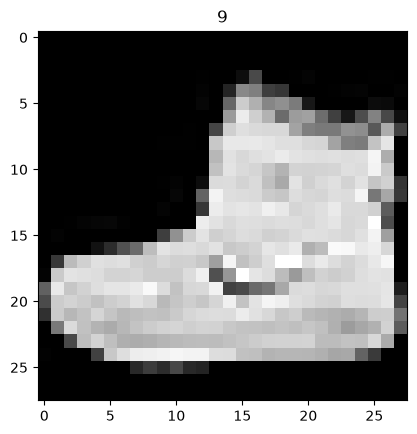

In [8]:
plt.imshow(image.squeeze(), cmap = 'gray')
plt.title(label)

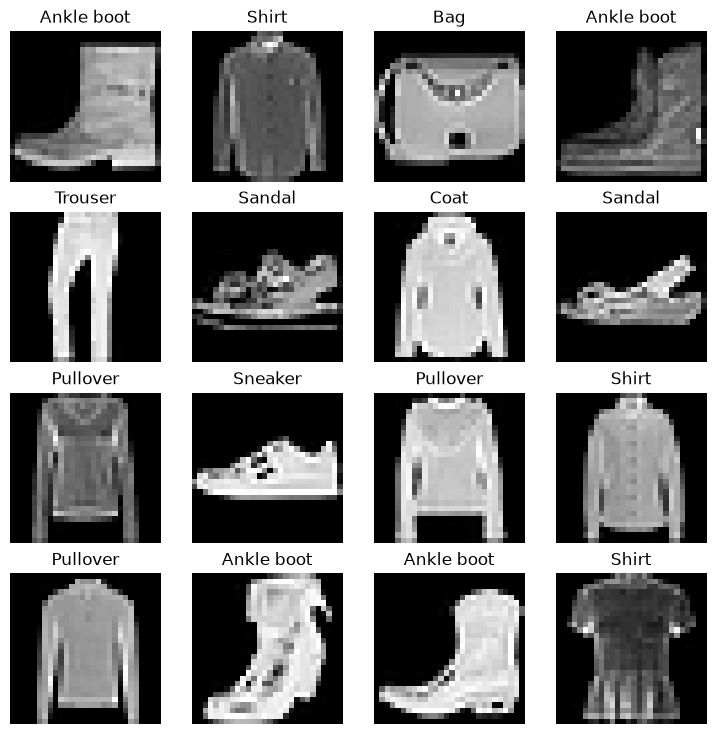

In [9]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_name[label])
    plt.axis(False)

In [10]:
from torch.utils.data import DataLoader

In [11]:
train_dataloader = DataLoader(train_data, batch_size = 32, shuffle = True)
test_dataloader = DataLoader(test_data, batch_size = 32, shuffle = False)

In [12]:
print(f"Dataloaders: {train_dataloader, test_dataloader}") 
print(f"Length of train dataloader: {len(train_dataloader)} batches of {train_dataloader.batch_size}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {test_dataloader.batch_size}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x000001E8A88D6BA0>, <torch.utils.data.dataloader.DataLoader object at 0x000001E8A8E07390>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [13]:
class nonCNNModel(torch.nn.Module):
    def __init__(self, input_shape: int, output_shape: int):
        super().__init__()

        self.layers = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features = input_shape, out_features = 64),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features = 64, out_features= 32),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features = 32, out_features = output_shape)
        )

    def forward(self, x):
        return self.layers(x)

In [14]:
model = nonCNNModel(input_shape = 784, output_shape = len(class_name))
model

nonCNNModel(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=10, bias=True)
  )
)

In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [16]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model.parameters(), lr = 0.1)

In [17]:
from timeit import default_timer as timer 
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [18]:
from torchmetrics import Accuracy

accuracy = Accuracy(task = 'multiclass', num_classes = len(class_name))

In [19]:
torch.manual_seed(42)

epoch = 10
train_time_start_on_cpu = timer()

for ep in range(epoch):

    print(f'epoch : {ep}')

    train_loss = 0

    for batch, (X, y) in enumerate(train_dataloader):

        model.train()

        y_pred = model(X)

        loss = loss_fn(y_pred, y)

        train_loss += loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if batch % 300 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    train_loss /= len(train_dataloader)
    test_loss, test_acc = 0, 0 

    model.eval()
    with torch.inference_mode():

        for batch, (X, y) in enumerate(test_dataloader):

            test_pred = model(X)

            test_loss += loss_fn(test_pred, y)

            test_acc += accuracy(test_pred, y)

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss:.5f} \t|\t Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, end=train_time_end_on_cpu, device=str(next(model.parameters()).device)) 
        

epoch : 0
Looked at 0/60000 samples
Looked at 9600/60000 samples
Looked at 19200/60000 samples
Looked at 28800/60000 samples
Looked at 38400/60000 samples
Looked at 48000/60000 samples
Looked at 57600/60000 samples

Train loss: 0.61039 	|	 Test loss: 0.46262, Test acc: 0.83%

epoch : 1
Looked at 0/60000 samples
Looked at 9600/60000 samples
Looked at 19200/60000 samples
Looked at 28800/60000 samples
Looked at 38400/60000 samples
Looked at 48000/60000 samples
Looked at 57600/60000 samples

Train loss: 0.41922 	|	 Test loss: 0.41858, Test acc: 0.85%

epoch : 2
Looked at 0/60000 samples
Looked at 9600/60000 samples
Looked at 19200/60000 samples
Looked at 28800/60000 samples
Looked at 38400/60000 samples
Looked at 48000/60000 samples
Looked at 57600/60000 samples

Train loss: 0.37829 	|	 Test loss: 0.39801, Test acc: 0.86%

epoch : 3
Looked at 0/60000 samples
Looked at 9600/60000 samples
Looked at 19200/60000 samples
Looked at 28800/60000 samples
Looked at 38400/60000 samples
Looked at 4800

In [20]:
gpu_train_dataloader = DataLoader(train_data, batch_size = 128, shuffle = True)
gpu_test_dataloader = DataLoader(test_data, batch_size = 128, shuffle = False)

print(f"Dataloaders: {train_dataloader, test_dataloader}") 
print(f"Length of train dataloader: {len(gpu_train_dataloader)} batches of {gpu_train_dataloader.batch_size}")
print(f"Length of test dataloader: {len(gpu_test_dataloader)} batches of {gpu_test_dataloader.batch_size}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x000001E8A88D6BA0>, <torch.utils.data.dataloader.DataLoader object at 0x000001E8A8E07390>)
Length of train dataloader: 469 batches of 128
Length of test dataloader: 79 batches of 128


In [21]:
gpu_model = nonCNNModel(input_shape = 784, output_shape = len(class_name)).to(device)
gpu_model

nonCNNModel(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=10, bias=True)
  )
)

In [22]:
optimizer = torch.optim.SGD(params = gpu_model.parameters(), lr = 0.1)

In [23]:
next(gpu_model.parameters()).device

device(type='cuda', index=0)

In [24]:
accuracy = accuracy.to(device)
accuracy.device

device(type='cuda', index=0)

In [25]:
def train_step(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, accuracy, device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy(y_pred, y)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

In [26]:
def test_step(data_loader: torch.utils.data.DataLoader, model: torch.nn.Module, loss_fn: torch.nn.Module, accuracy, device: torch.device = device):

    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() 
    with torch.inference_mode(): 
        for X, y in data_loader:

            X, y = X.to(device), y.to(device)
            
            test_pred = model(X)
            
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy(test_pred, y)
        
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [27]:
torch.manual_seed(42)

train_time_start_on_gpu = timer()

epochs = 10
for ep in range(epochs):
    train_step(data_loader=gpu_train_dataloader, 
        model = gpu_model, 
        loss_fn = loss_fn,
        optimizer = optimizer,
        accuracy = accuracy
    )
    test_step(data_loader=gpu_test_dataloader,
        model = gpu_model,
        loss_fn=loss_fn,
        accuracy = accuracy
    )

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu, end=train_time_end_on_gpu, device=device)

Train loss: 0.88451 | Train accuracy: 0.68%
Test loss: 0.59604 | Test accuracy: 0.78%

Train loss: 0.52484 | Train accuracy: 0.81%
Test loss: 0.49356 | Test accuracy: 0.82%

Train loss: 0.45612 | Train accuracy: 0.84%
Test loss: 0.46705 | Test accuracy: 0.83%

Train loss: 0.41819 | Train accuracy: 0.85%
Test loss: 0.43125 | Test accuracy: 0.85%

Train loss: 0.39252 | Train accuracy: 0.86%
Test loss: 0.43679 | Test accuracy: 0.84%

Train loss: 0.37080 | Train accuracy: 0.87%
Test loss: 0.46921 | Test accuracy: 0.83%

Train loss: 0.35922 | Train accuracy: 0.87%
Test loss: 0.38493 | Test accuracy: 0.86%

Train loss: 0.34524 | Train accuracy: 0.87%
Test loss: 0.38223 | Test accuracy: 0.86%

Train loss: 0.33343 | Train accuracy: 0.88%
Test loss: 0.37813 | Test accuracy: 0.86%

Train loss: 0.32457 | Train accuracy: 0.88%
Test loss: 0.36425 | Test accuracy: 0.87%

Train time on cuda: 98.377 seconds


In [28]:
class cnnModel(torch.nn.Module):
    def __init__(self, input_shape : int, no_of_kernels : int, output_shape : int):
        super().__init__()

        self.block1 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = input_shape, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1), 
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels = no_of_kernels, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1), 
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels = no_of_kernels, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1), 
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size = 2, stride = 2)
        )

        self.block2 = torch.nn.Sequential(
                torch.nn.Conv2d(in_channels = no_of_kernels, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1), 
                torch.nn.ReLU(),
                torch.nn.Conv2d(in_channels = no_of_kernels, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1), 
                torch.nn.ReLU(),                    
                torch.nn.MaxPool2d(kernel_size = 2)
        )

        self.classifierblock = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features = no_of_kernels * 7 * 7, out_features = output_shape)
        )

    def forward(self, x):
        return self.classifierblock(self.block2(self.block1(x)))

In [39]:
def train_cnn(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, accuracy, device: torch.device = device):
    train_loss, train_acc = 0, 0

    model.to(device)
    model.train()

    for X, y in data_loader:

        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)

        train_loss += loss.item()
        train_acc += accuracy(y_pred, y).item()

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)

    print(f'train loss : {train_loss:.4f}\t||\ttrain acc : {train_acc:.4f}')

In [40]:
def eval_cnn(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, accuracy, device: torch.device = device):
    test_loss, test_acc = 0, 0

    model.to(device)

    model.eval()

    with torch.inference_mode():

        for X, y in data_loader:

            X, y = X.to(device), y.to(device)
            
            y_pred = model(X)
            
            loss = loss_fn(y_pred, y)
            
            test_loss += loss.item()
            test_acc += accuracy(y_pred, y).item()

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

    print(f'test loss : {test_loss:.4f}\t||\ttest acc : {test_acc:.4f}')

In [41]:
device = 'cpu'
accuracy = Accuracy(task = 'multiclass', num_classes = len(class_name)).to(device)

cnn_model = cnnModel(input_shape = 1, no_of_kernels = 10, output_shape = len(class_name)).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = cnn_model.parameters(), lr = 0.01)

print(cnn_model)
next(cnn_model.parameters()).device, accuracy.device


cnnModel(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifierblock): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)


(device(type='cpu'), device(type='cpu'))

In [42]:
torch.manual_seed(42)

train_time_start_on_cpu = timer()

epochs = 10
for ep in range(epochs):
    print(f'epoch: {ep}\n')
    train_cnn(data_loader=train_dataloader, 
        model = cnn_model, 
        loss_fn = loss_fn,
        optimizer = optimizer,
        accuracy = accuracy
    )
    eval_cnn(data_loader=test_dataloader,
        model = cnn_model,
        loss_fn=loss_fn,
        optimizer = optimizer,
        accuracy = accuracy
    )

train_time_end_on_cpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_cpu, end=train_time_end_on_cpu, device=device)

epoch: 0

train loss : 1.9043	||	train acc : 0.2872
test loss : 0.7686	||	test acc : 0.7117
epoch: 1

train loss : 0.6105	||	train acc : 0.7805
test loss : 0.5237	||	test acc : 0.8077
epoch: 2

train loss : 0.4669	||	train acc : 0.8338
test loss : 0.4482	||	test acc : 0.8397
epoch: 3

train loss : 0.4114	||	train acc : 0.8525
test loss : 0.4055	||	test acc : 0.8573
epoch: 4

train loss : 0.3748	||	train acc : 0.8666
test loss : 0.3749	||	test acc : 0.8654
epoch: 5

train loss : 0.3483	||	train acc : 0.8757
test loss : 0.3579	||	test acc : 0.8759
epoch: 6

train loss : 0.3294	||	train acc : 0.8823
test loss : 0.3589	||	test acc : 0.8737
epoch: 7

train loss : 0.3164	||	train acc : 0.8865
test loss : 0.3260	||	test acc : 0.8826
epoch: 8

train loss : 0.3053	||	train acc : 0.8913
test loss : 0.3221	||	test acc : 0.8863
epoch: 9

train loss : 0.2980	||	train acc : 0.8935
test loss : 0.3293	||	test acc : 0.8793
Train time on cpu: 263.512 seconds


In [43]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

accuracy = Accuracy(task = 'multiclass', num_classes = len(class_name)).to(device)

on_gpu_cnn = cnnModel(input_shape = 1, no_of_kernels = 10, output_shape = len(class_name)).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = on_gpu_cnn.parameters(), lr = 0.01)

print(on_gpu_cnn)
next(on_gpu_cnn.parameters()).device, accuracy.device

cnnModel(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifierblock): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)


(device(type='cuda', index=0), device(type='cuda', index=0))

In [45]:
torch.manual_seed(42)

train_time_start_on_gpu = timer()

epochs = 10
for ep in range(epochs):
    print(f'\nepoch: {ep}\n')
    train_cnn(data_loader=train_dataloader, 
        model = on_gpu_cnn, 
        loss_fn = loss_fn,
        optimizer = optimizer,
        accuracy = accuracy
    )
    eval_cnn(data_loader=test_dataloader,
        model = on_gpu_cnn,
        loss_fn=loss_fn,
        optimizer = optimizer,
        accuracy = accuracy
    )

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu, end=train_time_end_on_gpu, device=device)


epoch: 0

train loss : 2.3011	||	train acc : 0.1221
test loss : 2.2903	||	test acc : 0.3568

epoch: 1

train loss : 0.9010	||	train acc : 0.6964
test loss : 0.5755	||	test acc : 0.7723

epoch: 2

train loss : 0.4898	||	train acc : 0.8198
test loss : 0.4606	||	test acc : 0.8327

epoch: 3

train loss : 0.4267	||	train acc : 0.8437
test loss : 0.4087	||	test acc : 0.8496

epoch: 4

train loss : 0.3922	||	train acc : 0.8569
test loss : 0.3948	||	test acc : 0.8577

epoch: 5

train loss : 0.3687	||	train acc : 0.8649
test loss : 0.3684	||	test acc : 0.8681

epoch: 6

train loss : 0.3502	||	train acc : 0.8725
test loss : 0.3706	||	test acc : 0.8664

epoch: 7

train loss : 0.3360	||	train acc : 0.8778
test loss : 0.3442	||	test acc : 0.8785

epoch: 8

train loss : 0.3234	||	train acc : 0.8829
test loss : 0.3389	||	test acc : 0.8823

epoch: 9

train loss : 0.3133	||	train acc : 0.8865
test loss : 0.3354	||	test acc : 0.8786
Train time on cuda: 285.215 seconds


In [46]:
y_preds = []
cnn_model.eval()
with torch.inference_mode():
  for X, y in test_dataloader:

    X, y = X.to('cpu'), y.to('cpu')

    y_logit = cnn_model(X)
    
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) 

    y_preds.append(y_pred)
y_pred_tensor = torch.cat(y_preds)

In [47]:
import mlxtend
mlxtend.__version__

'0.25.0'

In [48]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

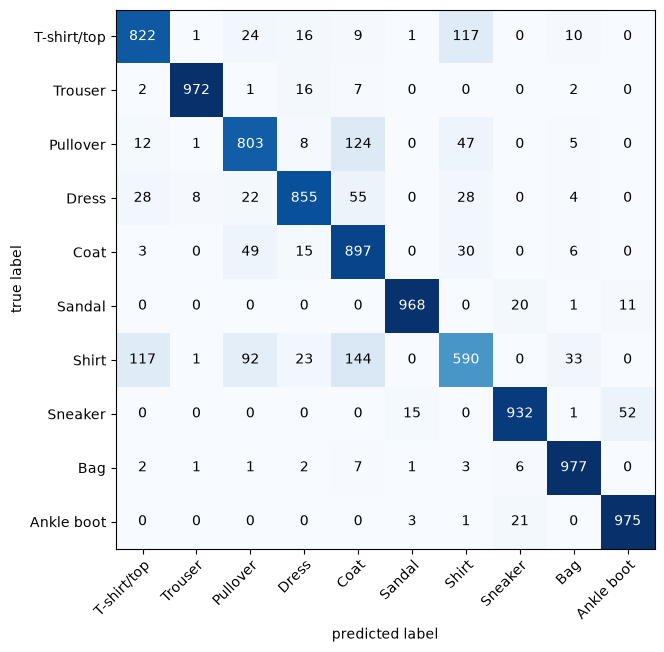

In [49]:
cm = ConfusionMatrix(task  ='multiclass', num_classes = len(class_name))
cm_tenors = cm(y_pred_tensor, test_data.targets)

fig, ax = plot_confusion_matrix(
    conf_mat=cm_tenors.numpy(),
    class_names=class_name,
    figsize=(10, 7)
)

In [56]:
on_gpu_cnn = on_gpu_cnn.to(device)
y_preds = []
on_gpu_cnn.eval()
with torch.inference_mode():
  for X, y in test_dataloader:

    X = X.to(device)

    y_logit = on_gpu_cnn(X)
    
    y_pred = y_logit.argmax(dim=1).cpu()

    y_preds.append(y_pred)
y_pred_tensor = torch.cat(y_preds)

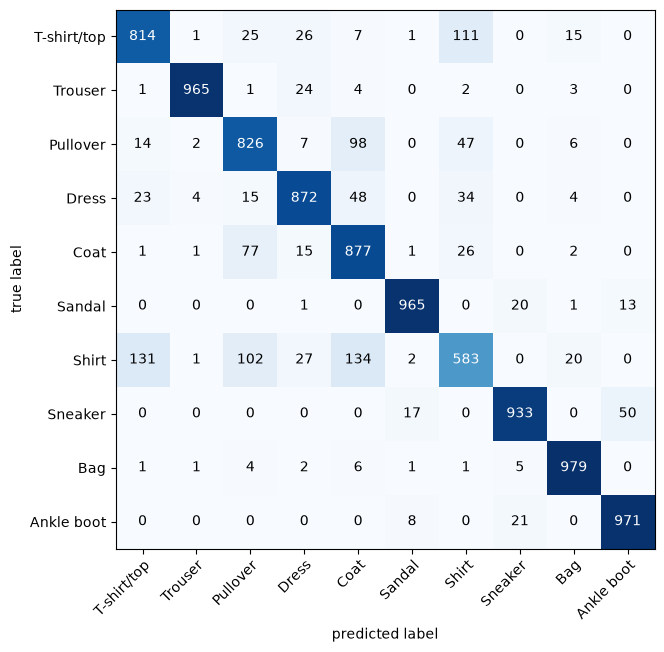

In [58]:
cm = ConfusionMatrix(task  ='multiclass', num_classes = len(class_name))
cm_tenors = cm(y_pred_tensor, test_data.targets)

fig, ax = plot_confusion_matrix(
    conf_mat=cm_tenors.numpy(),
    class_names=class_name,
    figsize=(10, 7)
)